<a href="https://colab.research.google.com/github/theyugster/Intro_To_ML/blob/main/Intro_to_ML(LogisticRegression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salihacur/diabetes")

print("Path to dataset files:", path)

100%|██████████| 8.91k/8.91k [00:00<00:00, 6.87MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/salihacur/diabetes/versions/2


In [4]:
import os
print(os.listdir(path))

['diabetes.csv']


In [6]:
df = pd.read_csv(f"{path}/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
feature_cols = ["Pregnancies","Glucose","BloodPressure","Insulin","BMI","Age",
"DiabetesPedigreeFunction"]
x = df[feature_cols]
y = df.Outcome
print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  Insulin   BMI  Age  \
0              6      148             72        0  33.6   50   
1              1       85             66        0  26.6   31   
2              8      183             64        0  23.3   32   
3              1       89             66       94  28.1   21   
4              0      137             40      168  43.1   33   
..           ...      ...            ...      ...   ...  ...   
763           10      101             76      180  32.9   63   
764            2      122             70        0  36.8   27   
765            5      121             72      112  26.2   30   
766            1      126             60        0  30.1   47   
767            1       93             70        0  30.4   23   

     DiabetesPedigreeFunction  
0                       0.627  
1                       0.351  
2                       0.672  
3                       0.167  
4                       2.288  
..                        ...  
763    

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(576, 7) (576,) (192, 7) (192,)


In [10]:
model = LogisticRegression(solver='lbfgs',max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [11]:
y_pred = model.predict(x_test)
print(y_pred)

[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0
 0 1 0 0 0 0 0]


In [13]:
conf_mat = metrics.confusion_matrix(y_test,y_pred)
print(conf_mat)
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

[[118  12]
 [ 26  36]]
0.8020833333333334


<Axes: xlabel='Predicted', ylabel='Actual'>

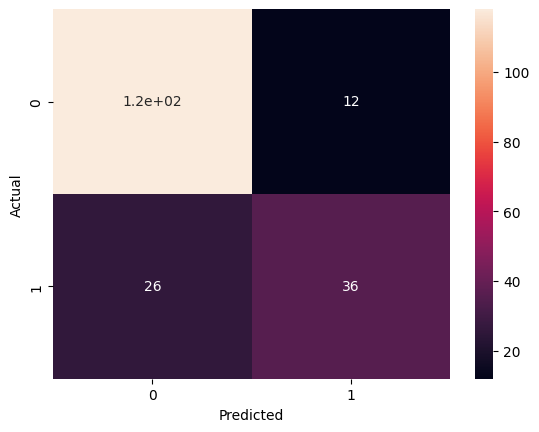

In [14]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["Predicted"])
sns.heatmap(conf_mat,annot=True)

In [15]:
url = "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta"
df = pd.read_stata(url)
df.head()

,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [16]:
df.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [17]:
feature_cols = ["gre","gpa","rank"]
x = df[feature_cols]
y=df.admit
print(x)
print(y)

       gre   gpa  rank
0    380.0  3.61   3.0
1    660.0  3.67   3.0
2    800.0  4.00   1.0
3    640.0  3.19   4.0
4    520.0  2.93   4.0
..     ...   ...   ...
395  620.0  4.00   2.0
396  560.0  3.04   3.0
397  460.0  2.63   2.0
398  700.0  3.65   2.0
399  600.0  3.89   3.0

[400 rows x 3 columns]
0      0.0
1      1.0
2      1.0
3      1.0
4      0.0
      ... 
395    0.0
396    0.0
397    0.0
398    0.0
399    0.0
Name: admit, Length: 400, dtype: float32


In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(300, 3) (300,) (100, 3) (100,)


In [19]:
model = LogisticRegression(solver='lbfgs',max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred = model.predict(x_test)
print(y_pred)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [21]:
conf_mat = metrics.confusion_matrix(y_test,y_pred)
print(conf_mat)
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

[[61  4]
 [27  8]]
0.69


<Axes: xlabel='Predicted', ylabel='Actual'>

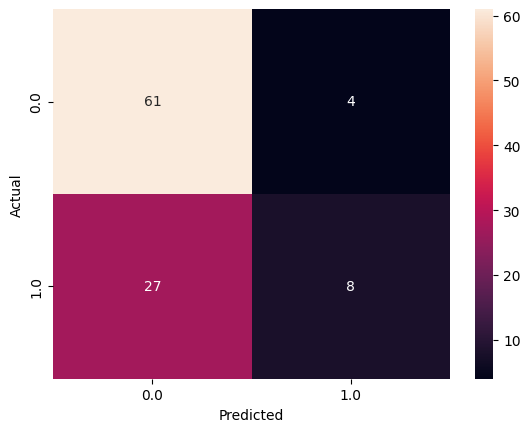

In [22]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["Predicted"])
sns.heatmap(conf_mat,annot=True)

In [24]:
df = pd.read_csv("/content/sample_data/numiqo.csv")
df.head()

,Disease,Age,Gender,Smoker status
0,diseased,43,Male,Smoker
1,not diseased,18,Male,Smoker
2,diseased,22,Female,Non-smoker
3,diseased,25,Male,Non-smoker
4,not diseased,45,Female,Smoker


In [26]:
df.shape

(36, 4)

In [29]:
df = pd.get_dummies(df, columns=['Gender', 'Smoker status'])

In [30]:
df.head()

,Disease,Age,Gender_Female,Gender_Male,Smoker status_Non-smoker,Smoker status_Smoker
0,diseased,43,False,True,False,True
1,not diseased,18,False,True,False,True
2,diseased,22,True,False,True,False
3,diseased,25,False,True,True,False
4,not diseased,45,True,False,False,True


In [31]:
df['Disease'] = df['Disease'].map({'diseased': 1, 'not diseased': 0})

In [32]:
df

,Disease,Age,Gender_Female,Gender_Male,Smoker status_Non-smoker,Smoker status_Smoker
0,1,43,False,True,False,True
1,0,18,False,True,False,True
2,1,22,True,False,True,False
3,1,25,False,True,True,False
4,0,45,True,False,False,True
5,0,12,False,True,True,False
6,1,23,False,True,False,True
7,1,33,False,True,False,True
8,0,27,False,True,True,False
9,0,27,True,False,True,False


In [45]:
feature_cols = ["Age","Gender_Male","Smoker status_Smoker"]
x = df[feature_cols]
y = df.Disease
print(x)
print(y)

    Age  Gender_Male  Smoker status_Smoker
0    43         True                  True
1    18         True                  True
2    22        False                 False
3    25         True                 False
4    45        False                  True
5    12         True                 False
6    23         True                  True
7    33         True                  True
8    27         True                 False
9    27        False                 False
10   48        False                  True
11   34        False                  True
12   32        False                  True
13   66         True                  True
14   24         True                  True
15   34         True                 False
16   27         True                 False
17   34        False                  True
18   55         True                  True
19   65         True                  True
20   44         True                  True
21   88         True                 False
22   33    

In [46]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(27, 3) (27,) (9, 3) (9,)


In [47]:
model = LogisticRegression(solver='lbfgs',max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [48]:
y_pred = model.predict(x_test)
print(y_pred)

[1 1 0 1 0 0 0 0 0]


In [49]:
conf_mat = metrics.confusion_matrix(y_test,y_pred)
print(conf_mat)
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

[[2 0]
 [4 3]]
0.5555555555555556


<Axes: xlabel='Predicted', ylabel='Actual'>

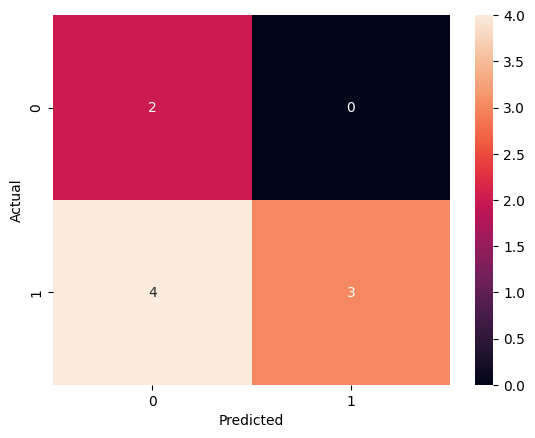

In [44]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["Predicted"])
sns.heatmap(conf_mat,annot=True)

In [52]:
df = pd.read_csv("/content/sample_data/customerML.csv")
df.head()

,Purchasing behaviour,Gender,Age,Time spent in online shop
0,Buy now,female,22,40
1,Buy now,female,25,23
2,Buy now,male,18,12
3,Buy now,male,45,28
4,Buy now,female,12,43


In [53]:
df = pd.get_dummies(df, columns=['Gender'])
df["Purchasing behaviour"] = df["Purchasing behaviour"].map({'Buy now':2,'Buy later':1,"Don't buy anything":0})
print(df)

    Purchasing behaviour  Age  Time spent in online shop  Gender_female  \
0                      2   22                         40           True   
1                      2   25                         23           True   
2                      2   18                         12          False   
3                      2   45                         28          False   
4                      2   12                         43           True   
5                      2   43                         23          False   
6                      2   23                         55          False   
7                      2   33                         34          False   
8                      1   27                         28           True   
9                      1   27                         15           True   
10                     1   48                        110          False   
11                     1   34                         28          False   
12                     1 

In [54]:
feature_cols = ["Age","Time spent in online shop","Gender_female"]
x = df[feature_cols]
y = df["Purchasing behaviour"]
print(x)
print(y)

    Age  Time spent in online shop  Gender_female
0    22                         40           True
1    25                         23           True
2    18                         12          False
3    45                         28          False
4    12                         43           True
5    43                         23          False
6    23                         55          False
7    33                         34          False
8    27                         28           True
9    27                         15           True
10   48                        110          False
11   34                         28          False
12   32                         11          False
13   66                         32          False
14   24                         23          False
15   34                         44           True
16   27                         55           True
17   34                         65           True
18   55                         56          False


In [55]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(18, 3) (18,) (6, 3) (6,)


In [56]:
model = LogisticRegression(solver='lbfgs',max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [57]:
y_pred = model.predict(x_test)
print(y_pred)

[2 0 0 2 0 1]


In [58]:
conf_mat = metrics.confusion_matrix(y_test,y_pred)
print(conf_mat)
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

[[2 0 0]
 [1 0 2]
 [0 1 0]]
0.3333333333333333


<Axes: xlabel='Predicted', ylabel='Actual'>

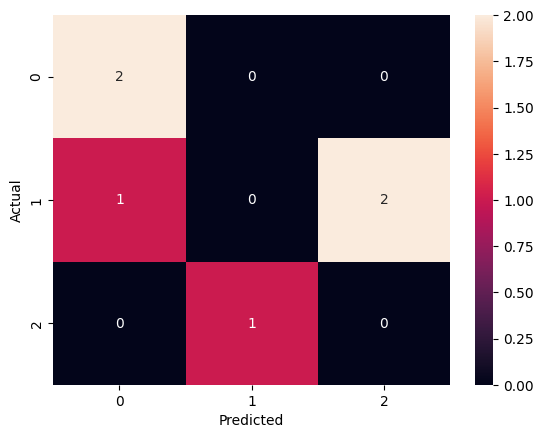

In [59]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["Predicted"])
sns.heatmap(conf_mat,annot=True)